# Taxonomie v3 : structure des arbres et biais de la dataviz

- Mesurer la répartition réelle des détections entre les arbres
- En déduire les biais assumés dans la visualisation

## Python stuff

In [1]:
import json
import statistics
from collections import Counter, defaultdict, deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Configs
DATA = Path("analysis_v3")
_ = plt.style.use("ggplot")

## 1 - Récupération et préparation des données

Source : livraison v3 de JB — `structure/taxonomy_32.json` (hiérarchie) et
`label/instances.json` (détections dans les textes).

In [2]:
topics = json.loads((DATA / "structure/taxonomy_32.json").read_text())["topics"]
docs = json.loads((DATA / "label/instances.json").read_text())["documents"]

by_id = {t["id"]: t for t in topics}
by_name = {t["name"]: t for t in topics}   # noms uniques en v3

own = defaultdict(int)
for d in docs:
    for lab in d["labels"]:
        own[lab["name"]] += 1
own = dict(own)

# le parent est un UUID en v3 --> on le résout vers le nom
parent_nom = {t["name"]: (by_id[t["parent"]]["name"] if t["parent"] in by_id else None)
              for t in topics}

print(f"ℹ️ {len(topics)} topics")
print(f"ℹ️ {len(docs)} documents analysés")

ℹ️ 4846 topics
ℹ️ 1524 documents analysés


### 1.1 - Filtre qualité

Un topic est **propre** s'il est relié à un arbre (pas isolé) et sans cycle.

In [3]:
est_parent = {p for p in parent_nom.values() if p}
isoles = {n for n in by_name if not parent_nom[n] and n not in est_parent}


def est_cyclique(nom: str, vus: set | None = None) -> bool:
    vus = vus or set()
    if nom in vus:
        return True
    vus.add(nom)
    p = parent_nom.get(nom)
    return est_cyclique(p, vus) if p and p in by_name else False


cycliques = {n for n in by_name if est_cyclique(n)}
propre = set(by_name) - isoles - cycliques

print(f"✅ {len(propre)} topics propres sur {len(by_name)}")
print(f"ℹ️ Écartés --> isolés : {len(isoles)} · cycliques : {len(cycliques)}")
print("ℹ️ Pour mémoire, la v1 comptait 1029 isolés et 78 cycles")

✅ 4835 topics propres sur 4846
ℹ️ Écartés --> isolés : 11 · cycliques : 0
ℹ️ Pour mémoire, la v1 comptait 1029 isolés et 78 cycles


### 1.2 - Construction des arbres

In [4]:
parent_de = {n: parent_nom[n] for n in propre if parent_nom[n] in propre}
enfants = defaultdict(list)
for n, p in parent_de.items():
    enfants[p].append(n)

_memo = {}
def rec(n: str) -> int:
    """Détections agrégées sur le sous-arbre."""
    if n not in _memo:
        _memo[n] = own.get(n, 0) + sum(rec(c) for c in enfants[n])
    return _memo[n]

def niv(n: str) -> int:
    return by_name[n]["level"]

def sous_arbre(r: str) -> set:
    vus, f = set(), deque([r])
    while f:
        x = f.popleft()
        if x in vus:
            continue
        vus.add(x)
        f.extend(enfants[x])
    return vus

def profondeur(r: str) -> int:
    """Arêtes de la racine à la feuille la plus lointaine."""
    d, f, mx = {r: 0}, deque([r]), 0
    while f:
        x = f.popleft()
        for c in enfants[x]:
            d[c] = d[x] + 1
            mx = max(mx, d[c])
            f.append(c)
    return mx

ROOTS = sorted((n for n in propre if n not in parent_de and rec(n) > 0),
               key=rec, reverse=True)
print(f"✅ {len(ROOTS)} arbres (racine propre portant au moins une détection)")

✅ 20 arbres (racine propre portant au moins une détection)


In [5]:
tab = pd.DataFrame([{
    "racine": r,
    "niv. racine": niv(r),
    "nœuds": len(sous_arbre(r)),
    "profondeur": profondeur(r),
    "feuilles": sum(1 for n in sous_arbre(r) if not enfants[n]),
    "détections": rec(r),
} for r in ROOTS])
tab.sort_values(by="profondeur", ascending=False)

,racine,niv. racine,nœuds,profondeur,feuilles,détections
0,sciences humaines et sociales,7,3667,7,3224,138713
1,sciences sociales,6,937,6,742,39315
2,"société, politique et organisation collective",4,115,4,86,5799
4,méthodes d'analyse et d'évaluation,4,23,4,11,572
5,développement et transformation des sociétés,4,8,4,3,337
11,technologies et transformations numériques,4,18,4,12,232
9,philosophie du travail,3,6,3,3,240
16,"recherche, données et connaissances",2,6,2,4,28
3,justice sociale et économique,2,7,2,5,586
7,réformes et politiques publiques,2,9,2,7,278


## 2 - Répartition des détections

In [6]:
TOT = tab["détections"].sum()
cumul = tab.sort_values("détections", ascending=False).copy()
cumul["% du total"] = (100 * cumul["détections"] / TOT).round(1)
cumul["% cumulé"] = cumul["% du total"].cumsum().round(1)
cumul[["racine", "nœuds", "détections", "% du total", "% cumulé"]].head(6)

,racine,nœuds,détections,% du total,% cumulé
0,sciences humaines et sociales,3667,138713,74.1,74.1
1,sciences sociales,937,39315,21.0,95.1
2,"société, politique et organisation collective",115,5799,3.1,98.2
3,justice sociale et économique,7,586,0.3,98.5
4,méthodes d'analyse et d'évaluation,23,572,0.3,98.8
5,développement et transformation des sociétés,8,337,0.2,99.0


In [7]:
print(f"ℹ️ {TOT} détections réparties sur {len(ROOTS)} arbres\n")
for k in (1, 2, 3, 5):
    part = cumul["détections"].head(k).sum()
    print(f"   {k:2d} arbre(s) sur {len(ROOTS)} --> {round(100 * part / TOT):3d} % des détections")

g = tab.iloc[0]
print(f"\nℹ️ « {g['racine']} » = {g['nœuds']} nœuds "
      f"= {round(100 * g['nœuds'] / len(propre))} % de la taxonomie propre")

ℹ️ 187307 détections réparties sur 20 arbres

    1 arbre(s) sur 20 -->  74 % des détections
    2 arbre(s) sur 20 -->  95 % des détections
    3 arbre(s) sur 20 -->  98 % des détections
    5 arbre(s) sur 20 -->  99 % des détections

ℹ️ « sciences humaines et sociales » = 3667 nœuds = 76 % de la taxonomie propre


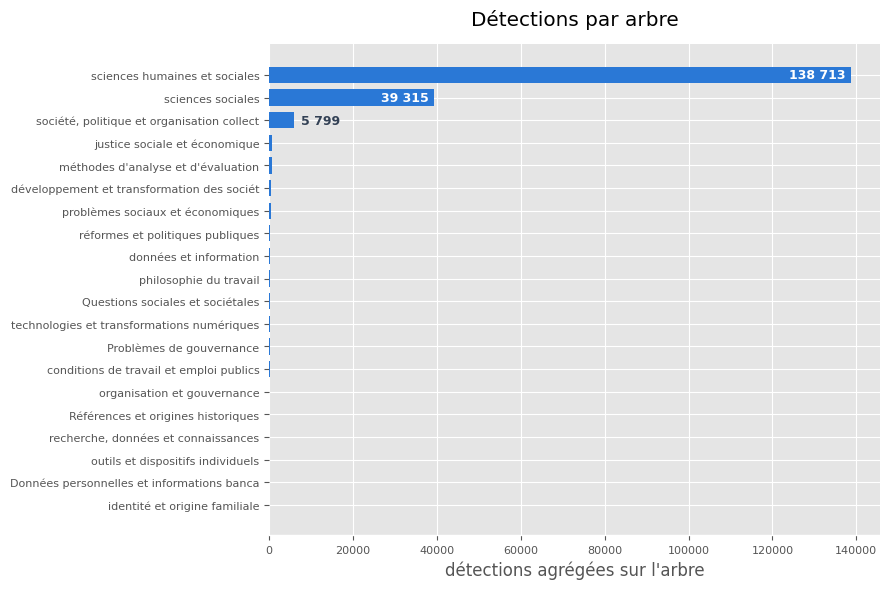

In [8]:
serie = cumul.sort_values("détections")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(serie["racine"].str.slice(0, 42), serie["détections"], color="#2a78d6", height=0.72)
ax.set_xlabel("détections agrégées sur l'arbre")
ax.set_title("Détections par arbre", pad=14)

xmax = serie["détections"].max()
for y, (_, ligne) in enumerate(serie.iterrows()):
    v = ligne["détections"]
    if v <= 5000:
        continue
    txt = f"{int(v):,}".replace(",", " ")
    dedans = v > 0.25 * xmax
    ax.text(v + (-0.01 if dedans else 0.012) * xmax, y, txt, va="center",
            ha="right" if dedans else "left",
            color="white" if dedans else "#334155", fontsize=9, fontweight="bold")

ax.tick_params(labelsize=8)
for bord in ("top", "right", "left"):
    ax.spines[bord].set_visible(False)
plt.tight_layout()
plt.show()

## 3 - Profondeur des arbres

In [9]:
print("ℹ️ « Aller jusqu'au bout » — trois lectures :\n")
print(f"   (a) atteindre une feuille de niveau 0 ........ "
      f"{sum(min(niv(n) for n in sous_arbre(r)) == 0 for r in ROOTS)}/{len(ROOTS)}")
print(f"   (b) traverser les 8 niveaux (profondeur ≥ 7) . "
      f"{sum(profondeur(r) >= 7 for r in ROOTS)}/{len(ROOTS)}")
print(f"   (c) avoir ≥ 4 générations (profondeur ≥ 4) ... "
      f"{sum(profondeur(r) >= 4 for r in ROOTS)}/{len(ROOTS)}")

print("\nℹ️ Répartition des profondeurs (en arêtes) :")
for p, c in sorted(Counter(profondeur(r) for r in ROOTS).items()):
    print(f"   profondeur {p} : {c} arbre(s)")

ℹ️ « Aller jusqu'au bout » — trois lectures :

   (a) atteindre une feuille de niveau 0 ........ 20/20
   (b) traverser les 8 niveaux (profondeur ≥ 7) . 1/20
   (c) avoir ≥ 4 générations (profondeur ≥ 4) ... 6/20

ℹ️ Répartition des profondeurs (en arêtes) :
   profondeur 1 : 6 arbre(s)
   profondeur 2 : 7 arbre(s)
   profondeur 3 : 1 arbre(s)
   profondeur 4 : 4 arbre(s)
   profondeur 6 : 1 arbre(s)
   profondeur 7 : 1 arbre(s)


## 4 - Le champ `level`

Question : peut-on s'en servir pour naviguer dans l'arbre ?

In [10]:
print(f"✅ `level` de la racine == profondeur réelle : "
      f"{sum(niv(r) == profondeur(r) for r in ROOTS)}/{len(ROOTS)} arbres\n")

print("ℹ️ Mais les racines sont réparties sur presque tous les niveaux :")
for lvl, c in sorted(Counter(niv(r) for r in ROOTS).items(), reverse=True):
    print(f"   niveau {lvl} : {c} racine(s)")

✅ `level` de la racine == profondeur réelle : 20/20 arbres

ℹ️ Mais les racines sont réparties sur presque tous les niveaux :
   niveau 7 : 1 racine(s)
   niveau 6 : 1 racine(s)
   niveau 4 : 4 racine(s)
   niveau 3 : 1 racine(s)
   niveau 2 : 7 racine(s)
   niveau 1 : 6 racine(s)


In [11]:
sauts = Counter(niv(parent_de[n]) - niv(n) for n in parent_de)
tot_e = sum(sauts.values())
print(f"ℹ️ Écart de `level` parent --> enfant (attendu +1), sur {tot_e} arêtes :")
for s in sorted(sauts):
    print(f"   {s:+d} : {sauts[s]:5d} arêtes ({round(100 * sauts[s] / tot_e):2d} %)")

feuilles = [n for n in propre if not enfants[n]]
print(f"\nℹ️ Feuilles déclarées à un niveau ≠ 0 : "
      f"{sum(1 for n in feuilles if niv(n) != 0)} sur {len(feuilles)}")

ℹ️ Écart de `level` parent --> enfant (attendu +1), sur 4815 arêtes :
   +1 :  4078 arêtes (85 %)
   +2 :   594 arêtes (12 %)
   +3 :   137 arêtes ( 3 %)
   +4 :     6 arêtes ( 0 %)

ℹ️ Feuilles déclarées à un niveau ≠ 0 : 23 sur 4121


## 5 - Ramification

In [12]:
internes = [n for n in propre if enfants[n]]
br = [len(enfants[n]) for n in internes]
chaines = sum(1 for b in br if b == 1)

print(f"ℹ️ {len(internes)} nœuds internes · {len(propre) - len(internes)} feuilles")
print(f"ℹ️ Enfants par nœud interne : médiane {int(statistics.median(br))}, "
      f"moyenne {statistics.mean(br):.1f}, max {max(br)}")
print(f"ℹ️ Nœuds « en chaîne » (1 seul enfant) : {chaines} "
      f"= {round(100 * chaines / len(internes))} % des internes")

ℹ️ 714 nœuds internes · 4121 feuilles
ℹ️ Enfants par nœud interne : médiane 3, moyenne 6.7, max 160
ℹ️ Nœuds « en chaîne » (1 seul enfant) : 163 = 23 % des internes


## 6 - Classement par navigabilité

Croisement taille × profondeur :

- **hiérarchie profonde** : ≥ 100 nœuds et ≥ 4 générations
- **arbuste** : ≥ 3 générations
- **buisson** : 2 niveaux
- **plat** : racine + feuilles

In [13]:
def classe(r: str) -> str:
    n, p = len(sous_arbre(r)), profondeur(r)
    if n >= 100 and p >= 4:
        return "hiérarchie profonde"
    if p >= 3:
        return "arbuste"
    if p == 2:
        return "buisson (2 niveaux)"
    return "plat (racine + feuilles)"

ORDRE = ["hiérarchie profonde", "arbuste", "buisson (2 niveaux)", "plat (racine + feuilles)"]
tab["classe"] = tab["racine"].map(classe)

resume = (tab.groupby("classe")
             .agg(arbres=("racine", "size"), détections=("détections", "sum"))
             .reindex(ORDRE).reset_index())
resume["% détections"] = (100 * resume["détections"] / TOT).round().astype(int)
resume

,classe,arbres,détections,% détections
0,hiérarchie profonde,3,183827,98
1,arbuste,4,1381,1
2,buisson (2 niveaux),7,1355,1
3,plat (racine + feuilles),6,744,0


In [14]:
detail = tab[["racine", "classe", "nœuds", "profondeur", "détections"]].copy()
detail["classe"] = pd.Categorical(detail["classe"], categories=ORDRE, ordered=True)
detail.sort_values(["classe", "détections"], ascending=[True, False])

,racine,classe,nœuds,profondeur,détections
0,sciences humaines et sociales,hiérarchie profonde,3667,7,138713
1,sciences sociales,hiérarchie profonde,937,6,39315
2,"société, politique et organisation collective",hiérarchie profonde,115,4,5799
4,méthodes d'analyse et d'évaluation,arbuste,23,4,572
5,développement et transformation des sociétés,arbuste,8,4,337
9,philosophie du travail,arbuste,6,3,240
11,technologies et transformations numériques,arbuste,18,4,232
3,justice sociale et économique,buisson (2 niveaux),7,2,586
7,réformes et politiques publiques,buisson (2 niveaux),9,2,278
8,données et information,buisson (2 niveaux),10,2,270


## 7 - Biais retenus pour la dataviz

| Biais | Motif | Ce que ça déforme |
|---|---|---|
| 3 paliers par hauteur — A (6–7), B (3–4), C (1–2) | §2, §3 | perte de la lecture « 20 arbres à égalité » |
| espace du cercle réparti par palier, pas au prorata | §2 | les petits arbres occupent une place sans rapport avec leur poids |
| couleur = profondeur depuis la racine, jamais `level` | §4 | on lit un rôle, pas une valeur absolue |
| affichage des premiers crans seulement | §3, §5 | la profondeur réelle n'apparaît qu'en descendant |

Outil d'exploration, **pas** représentation proportionnelle du corpus.